# Image Generation with GANs

This notebook demonstrates how to build and train a Generative Adversarial Network (GAN) to generate realistic face images from noise vectors. The architecture follows a DCGAN-style approach using a 64x64 cropped subset of the CelebA dataset.

We implement both the Generator and Discriminator models, train them adversarially, and visualize generated samples after training.

Author: Crystal Ford | GAN for face generation | May 2025

In [ ]:
from glob import glob
from typing import Tuple, Callable, Dict

import matplotlib.pyplot as plt
import numpy as np
import torch
from PIL import Image
from torch.utils.data import DataLoader, Dataset
from torchvision.transforms import Compose, ToTensor

## Data Preparation

The dataset consists of cropped and resized RGB face images at 64x64 resolution. We define a simple transform pipeline to normalize the data for training a GAN.

In [ ]:
from torchvision import transforms

def get_transforms(size: Tuple[int, int]) -> Callable:
    """Return transforms to resize, center crop, convert to tensor, and normalize images."""
    return transforms.Compose([
        transforms.Resize(size),
        transforms.CenterCrop(size),
        transforms.ToTensor(),  # Converts to [0, 1]
        transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))  # Normalize to [-1, 1]
    ])

## Custom Dataset Loader

This class loads images from a directory and applies the specified transformations. It supports JPG-formatted CelebA images.

In [27]:
from PIL import Image as PILImage
from torch.utils.data import Dataset

class DatasetDirectory(Dataset):
    """
    Custom dataset for loading images from a directory.
    
    Args:
        directory (str): Path to the image folder.
        transforms (callable, optional): Transformations to apply to each image.
        extension (str): File extension filter (default: '.jpg').
    """
    def __init__(self, directory: str, transforms: Callable = None, extension: str = '.jpg'):
        self.image_paths = glob(f"{directory}/*{extension}")
        self.transforms = transforms

    def __len__(self) -> int:
        return len(self.image_paths)

    def __getitem__(self, index: int) -> torch.Tensor:
        image_path = self.image_paths[index]
        image = PILImage.open(image_path).convert("RGB")
        if self.transforms:
            image = self.transforms(image)
        return image

The functions below will help you visualize images from the dataset.

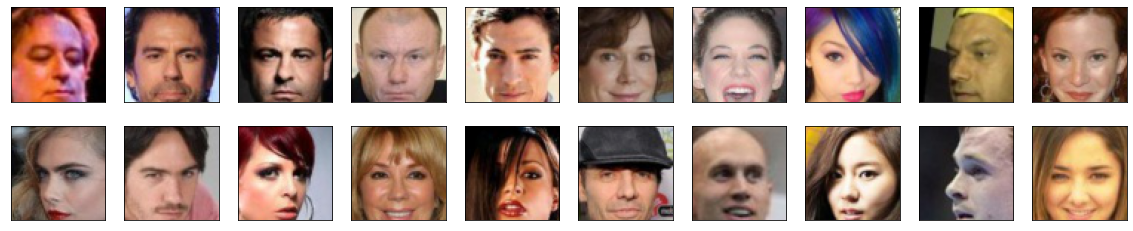

In [8]:
def denormalize(images):
    """Convert images from [-1, 1] range to [0, 255] uint8 format."""
    return ((images + 1.0) / 2.0 * 255).astype(np.uint8)

In [ ]:
# Visualize a batch of images from the dataset

import matplotlib.pyplot as plt
import numpy as np

fig = plt.figure(figsize=(20, 4))
plot_size = 20
for idx in np.arange(plot_size):
    ax = fig.add_subplot(2, int(plot_size / 2), idx + 1, xticks=[], yticks=[])
    img = dataset[idx].numpy()
    img = np.transpose(img, (1, 2, 0))
    img = denormalize(img)
    ax.imshow(img)

## GAN Architecture

This GAN consists of two adversarial networks:

- **Discriminator**: A CNN-based classifier that distinguishes real from fake images.
- **Generator**: A transposed CNN that upscales noise vectors into 64x64x3 RGB images.

Both follow the general architecture guidelines of DCGAN.

In [30]:
import torch.nn as nn

class Discriminator(nn.Module):
    def __init__(self):
        super(Discriminator, self).__init__()
        self.model = nn.Sequential(
            nn.Conv2d(3, 64, 4, stride=2, padding=1),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(64, 128, 4, stride=2, padding=1),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(128, 256, 4, stride=2, padding=1),
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(256, 512, 4, stride=2, padding=1),
            nn.BatchNorm2d(512),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(512, 1, 4, stride=1, padding=0),
            nn.Sigmoid()
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.model(x)

In [32]:
class Generator(nn.Module):
    def __init__(self, latent_dim: int):
        super(Generator, self).__init__()
        self.model = nn.Sequential(
            nn.ConvTranspose2d(latent_dim, 512, 4, stride=1, padding=0),
            nn.BatchNorm2d(512),
            nn.ReLU(True),

            nn.ConvTranspose2d(512, 256, 4, stride=2, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(True),

            nn.ConvTranspose2d(256, 128, 4, stride=2, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(True),

            nn.ConvTranspose2d(128, 64, 4, stride=2, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(True),

            nn.ConvTranspose2d(64, 3, 4, stride=2, padding=1),
            nn.Tanh()
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.model(x)

## Loss Functions & Optimizers

We use binary cross-entropy loss for both networks and Adam optimizers with beta values (0.5, 0.999), which are standard in GAN training.

In [34]:
import torch.optim as optim

def create_optimizers(generator: nn.Module, discriminator: nn.Module):
    """Create Adam optimizers for both the generator and discriminator."""
    learning_rate = 0.0002
    betas = (0.5, 0.999)

    g_optimizer = optim.Adam(generator.parameters(), lr=learning_rate, betas=betas)
    d_optimizer = optim.Adam(discriminator.parameters(), lr=learning_rate, betas=betas)
    
    return g_optimizer, d_optimizer

In [35]:
import torch.nn as nn

def generator_loss(fake_logits):
    """
    Generator loss. The goal is to fool the discriminator into thinking generated images are real.
    """
    criterion = nn.BCELoss()
    real_labels = torch.ones_like(fake_logits)
    return criterion(fake_logits, real_labels)

In [ ]:
def discriminator_loss(real_logits, fake_logits):
    """
    Discriminator loss. Penalizes incorrect classification of real and fake images.
    """
    criterion = nn.BCELoss()
    real_labels = torch.ones_like(real_logits)
    fake_labels = torch.zeros_like(fake_logits)

    real_loss = criterion(real_logits, real_labels)
    fake_loss = criterion(fake_logits, fake_labels)

    return real_loss + fake_loss

In [37]:
def discriminator_step(batch_size: int, latent_dim: int, real_images: torch.Tensor) -> Dict:
    """
    Perform one training step for the discriminator.
    """
    d_optimizer.zero_grad()

    noise = torch.randn(batch_size, latent_dim, 1, 1, device=real_images.device)
    fake_images = generator(noise)

    real_logits = discriminator(real_images)
    fake_logits = discriminator(fake_images.detach())

    d_loss = discriminator_loss(real_logits, fake_logits)
    d_loss.backward()
    d_optimizer.step()

    return {'loss': d_loss.item()}

In [38]:
def generator_step(batch_size: int, latent_dim: int) -> Dict:
    """
    Perform one training step for the generator.
    """
    g_optimizer.zero_grad()

    noise = torch.randn(batch_size, latent_dim, 1, 1, device=device)
    fake_images = generator(noise)

    fake_logits = discriminator(fake_images)
    g_loss = generator_loss(fake_logits)

    g_loss.backward()
    g_optimizer.step()

    return {'loss': g_loss.item()}

In [40]:
# you can experiment with different dimensions of latent spaces
latent_dim = 128

# update to cpu if you do not have access to a gpu
device = 'cuda'

# number of epochs to train your model
n_epochs = 35

# number of images in each batch
batch_size = 64

In [41]:
from torch.utils.data import DataLoader

# Hyperparameters
latent_dim = 128
n_epochs = 35
batch_size = 64
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Initialize models and optimizers
generator = Generator(latent_dim).to(device)
discriminator = Discriminator().to(device)
g_optimizer, d_optimizer = create_optimizers(generator, discriminator)

# Prepare dataset
dataset = DatasetDirectory('processed_celeba_small/celeba', get_transforms((64, 64)))
dataloader = DataLoader(dataset, 
                        batch_size=batch_size, 
                        shuffle=True, 
                        num_workers=4, 
                        drop_last=True)


--- Building Generator ---

--- Building Discriminator ---

--- Creating optimizers ---


In [43]:
def display(images: torch.Tensor):
    """
    Display a batch of generated images.
    
    Args:
        images (Tensor): Batch of images in [-1, 1] range, shape (N, 3, H, W)
    """
    fig = plt.figure(figsize=(14, 4))
    plot_size = min(16, images.size(0))
    for idx in range(plot_size):
        ax = fig.add_subplot(2, plot_size // 2, idx + 1, xticks=[], yticks=[])
        img = images[idx].detach().cpu().numpy()
        img = np.transpose(img, (1, 2, 0))
        img = denormalize(img)
        ax.imshow(img.astype(np.uint8))
    plt.show()

## Training Loop

The training loop alternates between updating the discriminator and generator. After each epoch, generated samples are saved to the `generated_faces/` directory for visual inspection.

In [45]:
from torchvision.utils import make_grid
import os

# Fixed noise for consistent sample generation
fixed_latent_vector = torch.randn(16, latent_dim, 1, 1, device=device)

# Create folder to save generated image samples
os.makedirs("generated_faces", exist_ok=True)

losses = []

for epoch in range(n_epochs):
    for batch_i, real_images in enumerate(dataloader):
        real_images = real_images.to(device)

        d_loss = discriminator_step(batch_size, latent_dim, real_images)
        g_loss = generator_step(batch_size, latent_dim)

        if batch_i % 50 == 0:
            d = d_loss['loss']
            g = g_loss['loss']
            losses.append((d, g))
            print(f"Epoch [{epoch+1}/{n_epochs}] | Batch {batch_i}/{len(dataloader)} | d_loss: {d:.4f} | g_loss: {g:.4f}")

    # Generate and save sample images at the end of each epoch
    generator.eval()
    with torch.no_grad():
        generated_images = generator(fixed_latent_vector)

    images = (generated_images + 1) / 2  # Rescale from [-1, 1] to [0, 1]
    grid = make_grid(images, nrow=4)

    filename = f"generated_faces/epoch_{epoch+1:02d}.png"
    plt.figure(figsize=(6, 6))
    plt.axis("off")
    plt.imshow(np.transpose(grid.cpu().numpy(), (1, 2, 0)))
    plt.savefig(filename)
    plt.close()

    generator.train()

>>> Training is starting now...
2025-05-06 02:19:07 | Epoch [1/35] | Batch 0/509 | d_loss: 1.3002 | g_loss: 1.3967
2025-05-06 02:19:13 | Epoch [1/35] | Batch 50/509 | d_loss: 0.1701 | g_loss: 14.8698
2025-05-06 02:19:19 | Epoch [1/35] | Batch 100/509 | d_loss: 0.2498 | g_loss: 4.9145
2025-05-06 02:19:26 | Epoch [1/35] | Batch 150/509 | d_loss: 0.2938 | g_loss: 4.1344
2025-05-06 02:19:32 | Epoch [1/35] | Batch 200/509 | d_loss: 0.4565 | g_loss: 4.2988
2025-05-06 02:19:38 | Epoch [1/35] | Batch 250/509 | d_loss: 0.4655 | g_loss: 7.3503
2025-05-06 02:19:44 | Epoch [1/35] | Batch 300/509 | d_loss: 0.3977 | g_loss: 2.6743
2025-05-06 02:19:50 | Epoch [1/35] | Batch 350/509 | d_loss: 0.6625 | g_loss: 2.8481
2025-05-06 02:19:56 | Epoch [1/35] | Batch 400/509 | d_loss: 0.4918 | g_loss: 5.2974
2025-05-06 02:20:02 | Epoch [1/35] | Batch 450/509 | d_loss: 0.1490 | g_loss: 4.6590
2025-05-06 02:20:08 | Epoch [1/35] | Batch 500/509 | d_loss: 0.3168 | g_loss: 3.2771
2025-05-06 02:20:12 | Epoch [2/35] 

2025-05-06 02:28:40 | Epoch [9/35] | Batch 450/509 | d_loss: 0.2427 | g_loss: 2.3505
2025-05-06 02:28:46 | Epoch [9/35] | Batch 500/509 | d_loss: 0.1429 | g_loss: 5.2551
2025-05-06 02:28:51 | Epoch [10/35] | Batch 0/509 | d_loss: 4.4162 | g_loss: 2.5206
2025-05-06 02:28:57 | Epoch [10/35] | Batch 50/509 | d_loss: 0.2605 | g_loss: 2.8728
2025-05-06 02:29:03 | Epoch [10/35] | Batch 100/509 | d_loss: 0.3276 | g_loss: 1.0629
2025-05-06 02:29:09 | Epoch [10/35] | Batch 150/509 | d_loss: 0.7134 | g_loss: 0.8759
2025-05-06 02:29:15 | Epoch [10/35] | Batch 200/509 | d_loss: 0.1246 | g_loss: 3.9917
2025-05-06 02:29:21 | Epoch [10/35] | Batch 250/509 | d_loss: 0.1751 | g_loss: 3.4011
2025-05-06 02:29:27 | Epoch [10/35] | Batch 300/509 | d_loss: 0.1406 | g_loss: 3.1165
2025-05-06 02:29:33 | Epoch [10/35] | Batch 350/509 | d_loss: 0.1151 | g_loss: 2.8551
2025-05-06 02:29:39 | Epoch [10/35] | Batch 400/509 | d_loss: 0.1180 | g_loss: 6.0503
2025-05-06 02:29:45 | Epoch [10/35] | Batch 450/509 | d_los

2025-05-06 02:38:04 | Epoch [18/35] | Batch 300/509 | d_loss: 7.4504 | g_loss: 10.2537
2025-05-06 02:38:10 | Epoch [18/35] | Batch 350/509 | d_loss: 0.0303 | g_loss: 5.2092
2025-05-06 02:38:16 | Epoch [18/35] | Batch 400/509 | d_loss: 0.0623 | g_loss: 4.1407
2025-05-06 02:38:22 | Epoch [18/35] | Batch 450/509 | d_loss: 0.0628 | g_loss: 5.4431
2025-05-06 02:38:28 | Epoch [18/35] | Batch 500/509 | d_loss: 0.0132 | g_loss: 7.3373
2025-05-06 02:38:33 | Epoch [19/35] | Batch 0/509 | d_loss: 0.0470 | g_loss: 4.4404
2025-05-06 02:38:39 | Epoch [19/35] | Batch 50/509 | d_loss: 0.1655 | g_loss: 6.2161
2025-05-06 02:38:45 | Epoch [19/35] | Batch 100/509 | d_loss: 0.6380 | g_loss: 2.6502
2025-05-06 02:38:51 | Epoch [19/35] | Batch 150/509 | d_loss: 0.0176 | g_loss: 5.4829
2025-05-06 02:38:57 | Epoch [19/35] | Batch 200/509 | d_loss: 0.0521 | g_loss: 6.2988
2025-05-06 02:39:03 | Epoch [19/35] | Batch 250/509 | d_loss: 0.1074 | g_loss: 5.6277
2025-05-06 02:39:09 | Epoch [19/35] | Batch 300/509 | d_

2025-05-06 02:47:27 | Epoch [27/35] | Batch 150/509 | d_loss: 0.0321 | g_loss: 8.1393
2025-05-06 02:47:33 | Epoch [27/35] | Batch 200/509 | d_loss: 0.1034 | g_loss: 7.3558
2025-05-06 02:47:39 | Epoch [27/35] | Batch 250/509 | d_loss: 0.0964 | g_loss: 10.7352
2025-05-06 02:47:45 | Epoch [27/35] | Batch 300/509 | d_loss: 0.0025 | g_loss: 8.3437
2025-05-06 02:47:51 | Epoch [27/35] | Batch 350/509 | d_loss: 0.3122 | g_loss: 5.5207
2025-05-06 02:47:57 | Epoch [27/35] | Batch 400/509 | d_loss: 1.3809 | g_loss: 3.3272
2025-05-06 02:48:03 | Epoch [27/35] | Batch 450/509 | d_loss: 2.6125 | g_loss: 7.4750
2025-05-06 02:48:09 | Epoch [27/35] | Batch 500/509 | d_loss: 0.0840 | g_loss: 4.3578
2025-05-06 02:48:14 | Epoch [28/35] | Batch 0/509 | d_loss: 0.0193 | g_loss: 5.1842
2025-05-06 02:48:20 | Epoch [28/35] | Batch 50/509 | d_loss: 0.0299 | g_loss: 6.0691
2025-05-06 02:48:26 | Epoch [28/35] | Batch 100/509 | d_loss: 0.0249 | g_loss: 5.2222
2025-05-06 02:48:32 | Epoch [28/35] | Batch 150/509 | d_

## Output Samples & Evaluation

The model generates a 4x4 grid of face samples using a fixed latent vector after each epoch. These can be used to evaluate visual progress over time.

Final training loss curves are shown below.

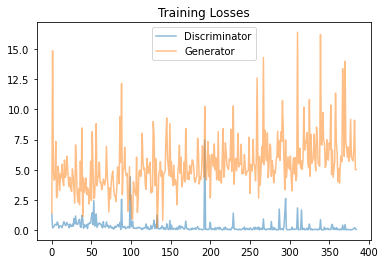

In [46]:
import numpy as np
import matplotlib.pyplot as plt

# Plot training losses for discriminator and generator
losses = np.array(losses)

plt.figure(figsize=(10, 5))
plt.plot(losses.T[0], label='Discriminator Loss', alpha=0.6)
plt.plot(losses.T[1], label='Generator Loss', alpha=0.6)
plt.title("Training Losses")
plt.xlabel("Iterations (per 50 batches)")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

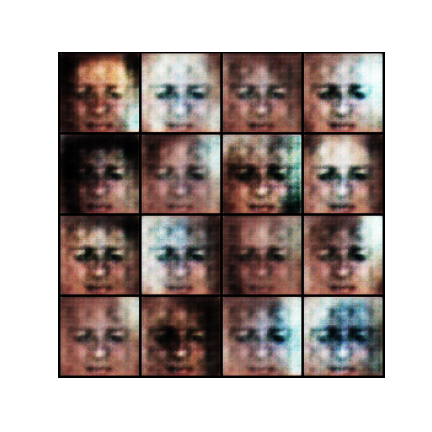

In [47]:
from IPython.display import Image, display

# Adjust this if you're looking for a specific epoch image
display(Image(filename="generated_faces/epoch_01.png"))
